In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st


from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, roc_curve, roc_auc_score
)
from time import time



In [ ]:
url_train = "https://raw.githubusercontent.com/serenantonini/ml_dataset/refs/heads/main/train.csv"
url_test = "https://raw.githubusercontent.com/serenantonini/ml_dataset/refs/heads/main/test.csv"

train_df = pd.read_csv(url_train)
test_df = pd.read_csv(url_test)

df_eda = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
df_eda = df_eda.drop(['id'], axis=1)

print(f"Dimensioni dataset unito per analisi: {df_eda.shape}\n")

X = train_df.drop(['target', 'id'], axis=1)
y = train_df['target']

X_test = test_df.drop(['target', 'id'], axis=1)
y_test = test_df['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

print(f"Training set:   {X_train.shape[0]} righe")
print(f"Validation set: {X_val.shape[0]} righe")
print(f"Test set:       {X_test.shape[0]} righe")
print(f"Numero di feature EEG: {len(X_train.columns)}")

Dimensioni dataset unito per analisi: (14980, 15)

Training set:   7984 righe
Validation set: 1996 righe
Test set:       5000 righe
Numero di feature EEG: 14


In [ ]:
print("--- PRIME 5 RIGHE (Head) ---")
display(df_eda.head())

print("\n--- INFORMAZIONI SUL DATASET (Info) ---")
df_eda.info()

print("\n--- CONTROLLO VALORI NULLI ---")
null_counts = df_eda.isnull().sum()
if null_counts.sum() == 0:
    print("Nessun valore nullo trovato nel dataset.")
else:
    print(null_counts[null_counts > 0])

print("\n--- STATISTICHE DESCRITTIVE (Describe) ---")
display(df_eda.describe().T)

--- PRIME 5 RIGHE (Head) ---


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,target
0,4313.33,4008.72,4261.03,4090.26,4342.56,4626.15,4078.46,4633.85,4237.95,4274.87,4236.41,4304.62,4633.33,4386.67,0
1,4316.92,4016.92,4262.56,4101.03,4344.62,4632.31,4082.05,4643.08,4248.21,4286.15,4250.26,4311.79,4642.56,4390.77,0
2,4321.03,4018.46,4262.56,4107.69,4345.13,4639.49,4088.72,4645.64,4251.79,4284.10,4248.21,4312.82,4640.51,4387.69,0
3,4318.97,4009.23,4265.13,4102.56,4339.49,4637.95,4090.26,4649.23,4255.90,4283.08,4240.00,4311.79,4635.90,4369.23,0
4,4305.13,3997.95,4265.64,4093.85,4331.79,4635.90,4088.72,4650.26,4252.31,4287.69,4237.44,4308.21,4628.72,4355.38,0



--- INFORMAZIONI SUL DATASET (Info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14980 entries, 0 to 14979
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AF3     14980 non-null  float64
 1   F7      14980 non-null  float64
 2   F3      14980 non-null  float64
 3   FC5     14980 non-null  float64
 4   T7      14980 non-null  float64
 5   P7      14980 non-null  float64
 6   O1      14980 non-null  float64
 7   O2      14980 non-null  float64
 8   P8      14980 non-null  float64
 9   T8      14980 non-null  float64
 10  FC6     14980 non-null  float64
 11  F4      14980 non-null  float64
 12  F8      14980 non-null  float64
 13  AF4     14980 non-null  float64
 14  target  14980 non-null  int64  
dtypes: float64(14), int64(1)
memory usage: 1.7 MB

--- CONTROLLO VALORI NULLI ---
Nessun valore nullo trovato nel dataset.

--- STATISTICHE DESCRITTIVE (Describe) ---


,count,mean,std,min,25%,50%,75%,max
AF3,14980.0,4321.772476,2492.205150,1030.7700,4281.54,4294.36,4311.28,309231.00
F7,14980.0,4011.538024,55.152398,2830.7700,3991.79,4006.15,4024.10,7804.62
F3,14980.0,4265.932872,46.743797,1040.0000,4251.79,4263.08,4273.85,6880.51
FC5,14980.0,4166.480566,5216.412507,2453.3300,4108.72,4121.03,4134.36,642564.00
T7,14980.0,4343.430122,39.923295,2089.7400,4332.82,4340.00,4348.72,6474.36
P7,14980.0,4646.054304,2924.817273,2768.2100,4613.33,4618.46,4627.69,362564.00
O1,14980.0,4108.649844,4600.944298,2086.1500,4056.92,4067.69,4081.03,567179.00
O2,14980.0,4618.121698,36.706733,4567.6900,4606.67,4614.87,4625.13,7264.10
P8,14980.0,4219.536572,2136.412500,1357.9500,4190.77,4200.00,4209.23,265641.00
T8,14980.0,4232.731870,43.384379,1816.4100,4221.03,4229.74,4240.51,6674.36


Bilanciamento Target (Pre-Cleaning):
target
0    56.141522
1    43.858478
Name: proportion, dtype: float64


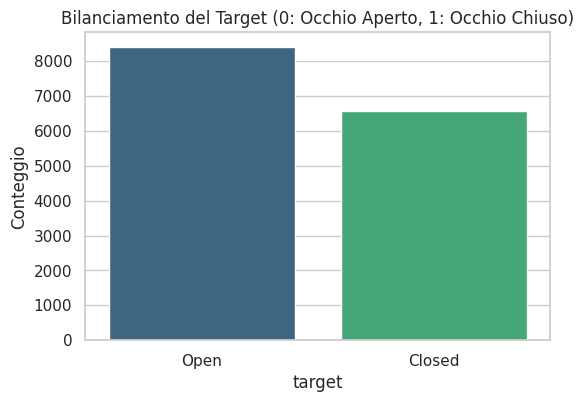

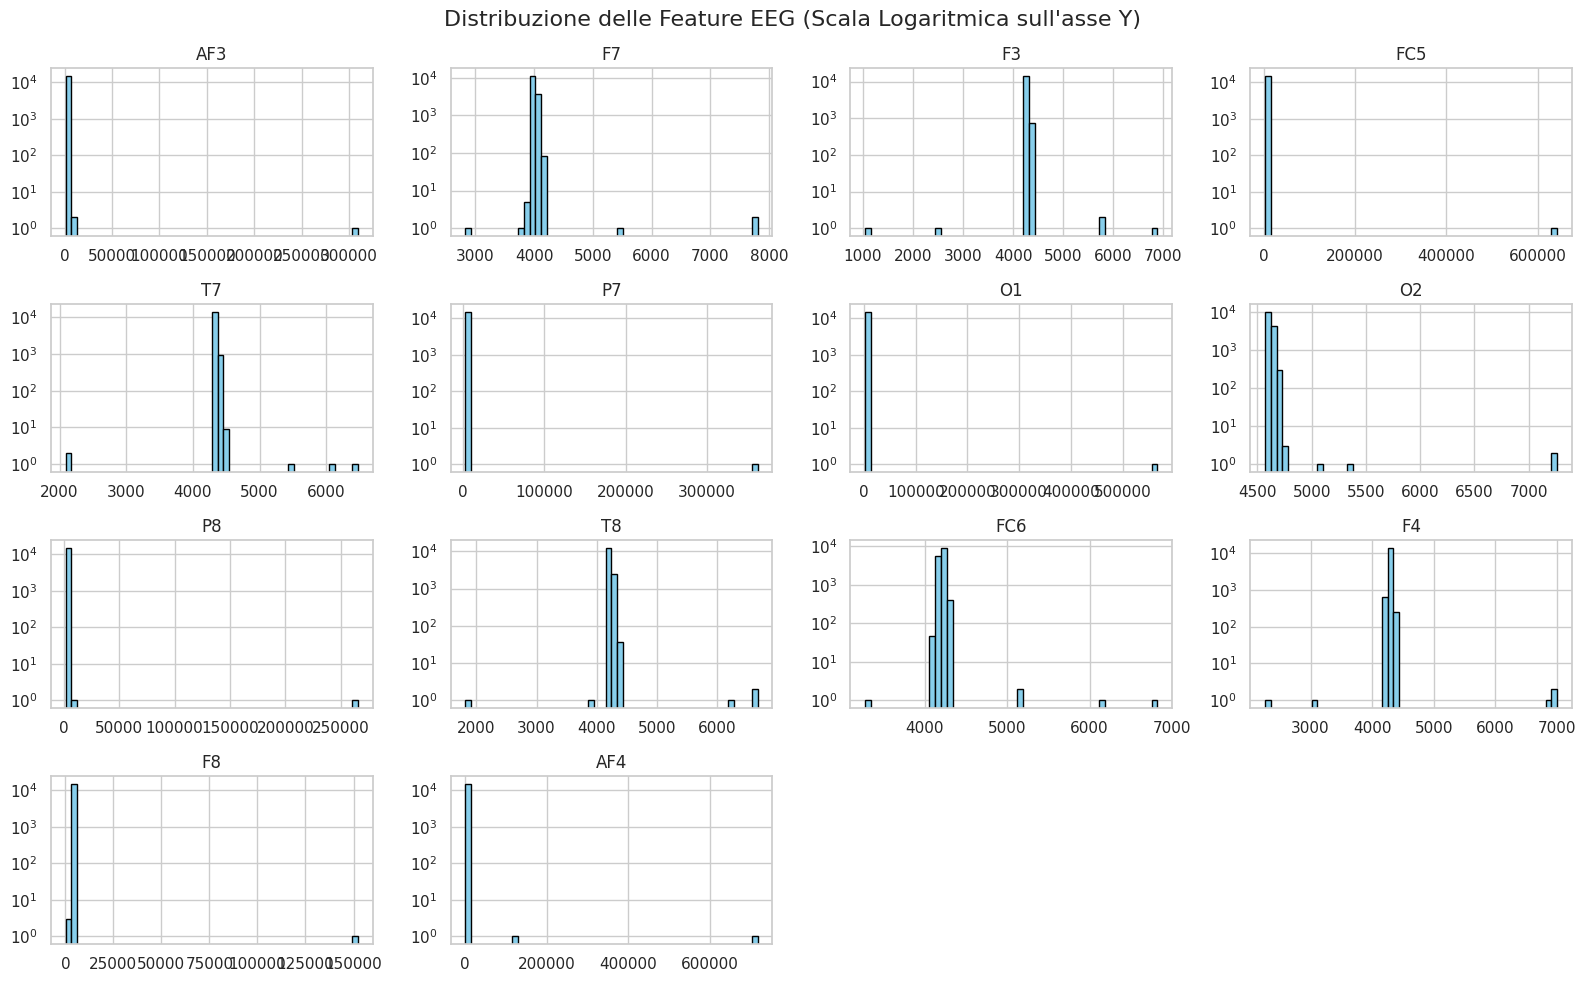

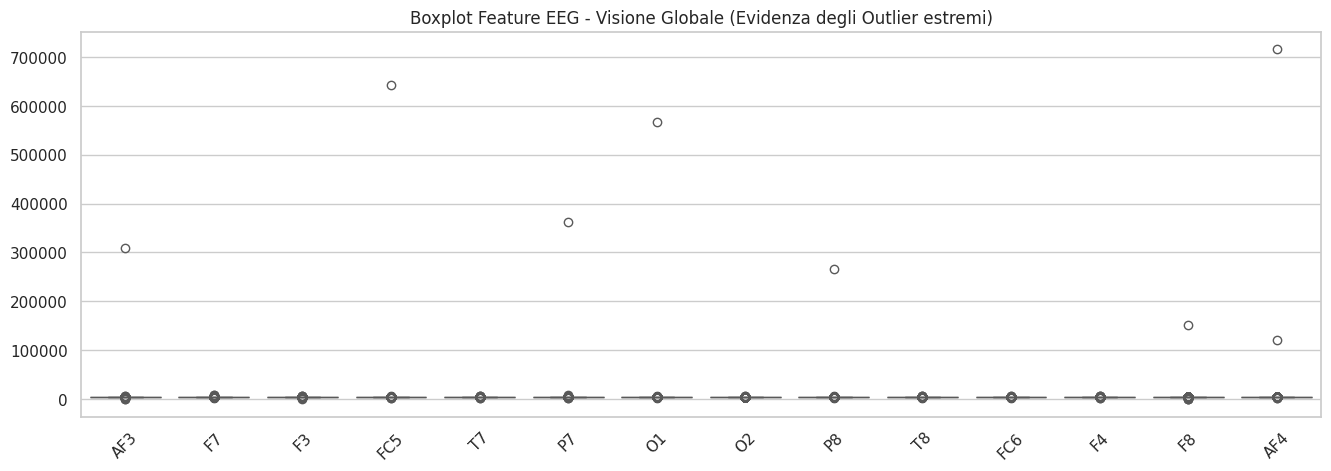

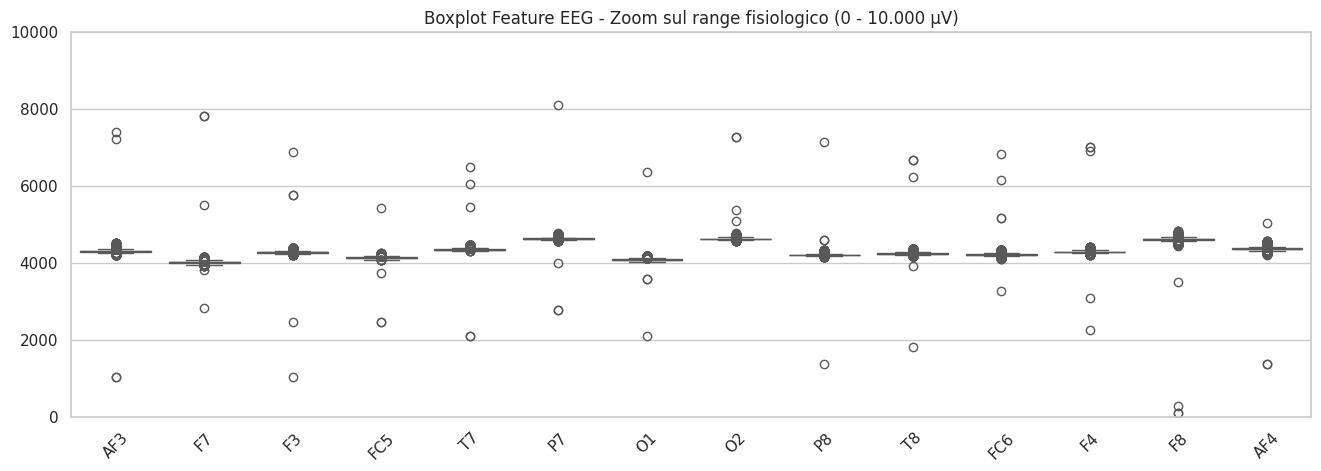

In [ ]:
sns.set_theme(style="whitegrid")

# BILANCIAMENTO TARGET
print("Bilanciamento Target (Pre-Cleaning):")
print(df_eda['target'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df_eda, x='target', hue='target', palette='viridis', legend=False)
plt.title("Bilanciamento del Target (0: Occhio Aperto, 1: Occhio Chiuso)")
plt.xticks([0, 1], ['Open', 'Closed'])
plt.ylabel("Conteggio")
plt.show()

# DISTRIBUZIONE DELLE FEATURE
df_eda.drop('target', axis=1).hist(figsize=(16, 10), bins=50, color='skyblue', edgecolor='black', log=True)
plt.suptitle("Distribuzione delle Feature EEG (Scala Logaritmica sull'asse Y)", fontsize=16)
plt.tight_layout()
plt.show()

# RICERCA DEGLI OUTLIER
plt.figure(figsize=(16, 5))
sns.boxplot(data=df_eda.drop('target', axis=1), palette='Set2')
plt.title("Boxplot Feature EEG - Visione Globale (Evidenza degli Outlier estremi)")
plt.xticks(rotation=45)
plt.show()

# BOXPLOT con focus sul range fisiologico
plt.figure(figsize=(16, 5))
sns.boxplot(data=df_eda.drop('target', axis=1), palette='Set2')
plt.title("Boxplot Feature EEG - Zoom sul range fisiologico (0 - 10.000 µV)")
plt.ylim(0, 10000)
plt.xticks(rotation=45)
plt.show()

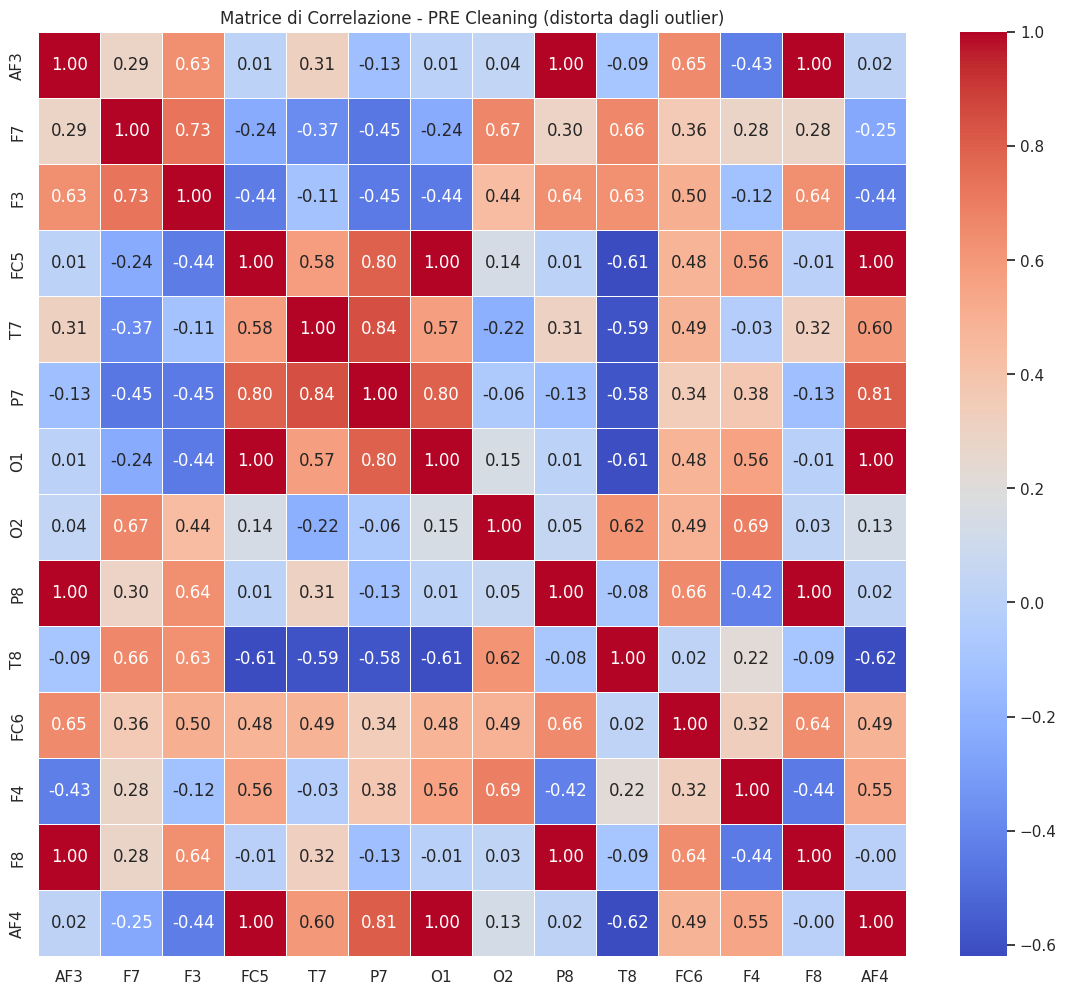

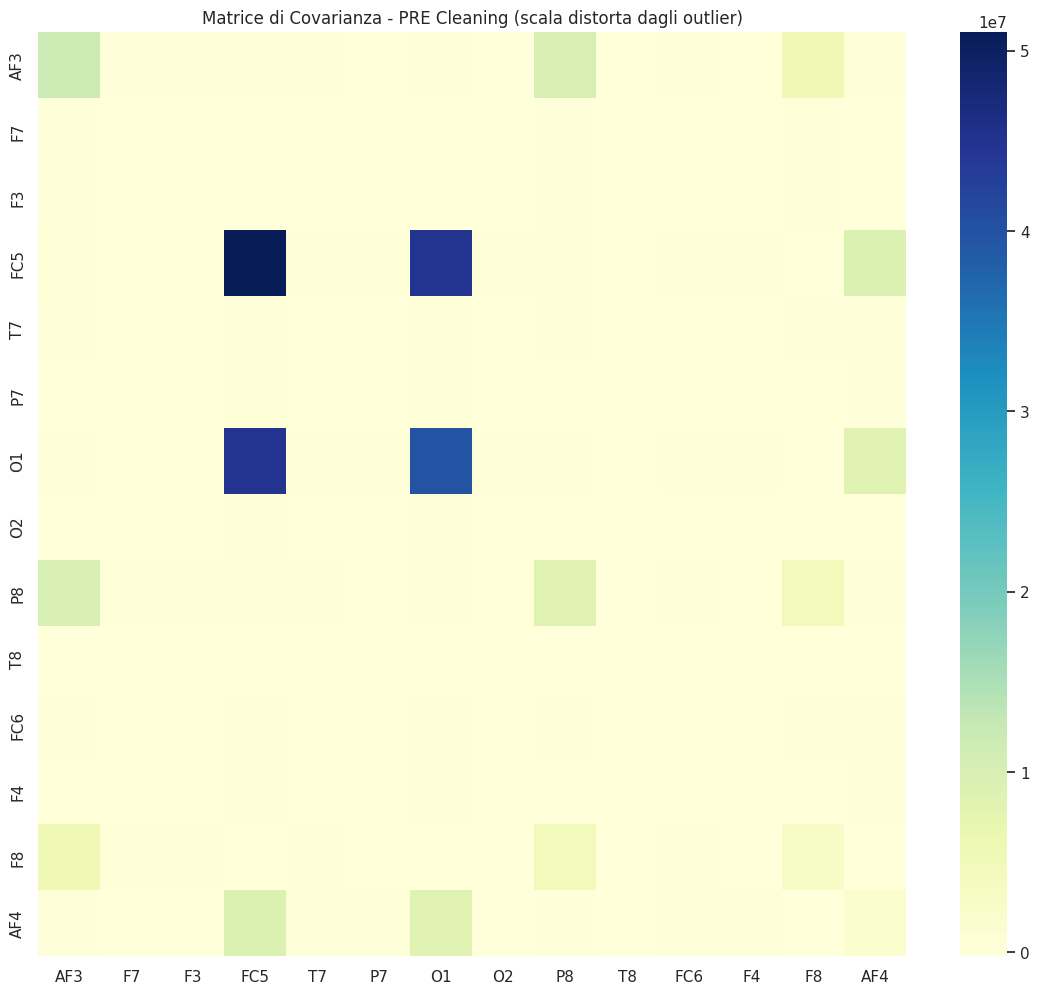

In [ ]:
# Matrice di Correlazione PRE-cleaning
plt.figure(figsize=(14, 12))
corr_pre = X_train.corr()
sns.heatmap(corr_pre, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Matrice di Correlazione - PRE Cleaning (distorta dagli outlier)")
plt.show()

# Matrice di Covarianza PRE-cleaning
plt.figure(figsize=(14, 12))
cov_pre = X_train.cov()
sns.heatmap(cov_pre, annot=False, cmap='YlGnBu')
plt.title("Matrice di Covarianza - PRE Cleaning (scala distorta dagli outlier)")
plt.show()

Righe originali in X_train: 7984
Righe pulite in X_train:    6447
Outlier eliminati:          1537

Bilanciamento Target (Post-Cleaning):
target
0    56.786102
1    43.213898
Name: proportion, dtype: float64

Righe validation: 1996 (invariato)
Righe test      : 5000 (invariato)

Feature a bassa varianza:
Nessuna (tutti gli elettrodi sono informativi)

Feature altamente correlate (>0.95):
Nessuna


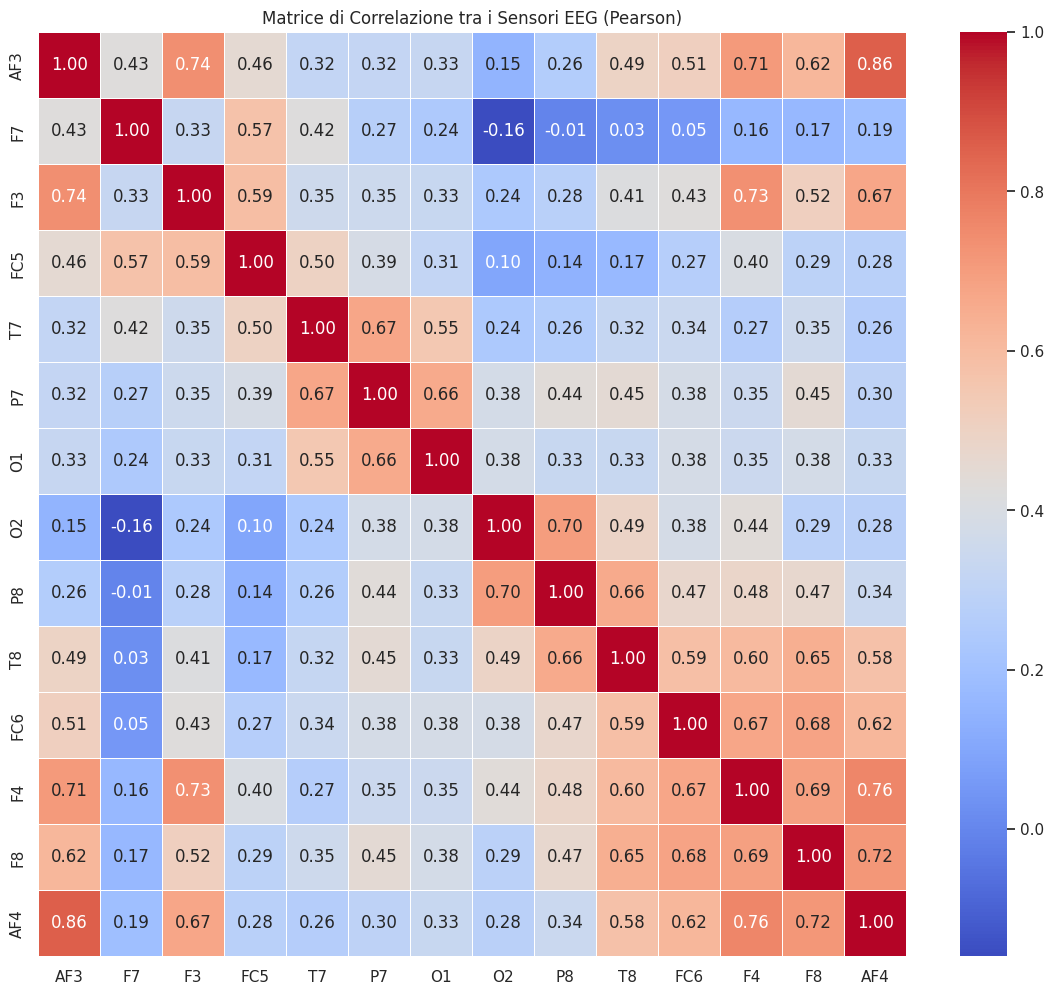

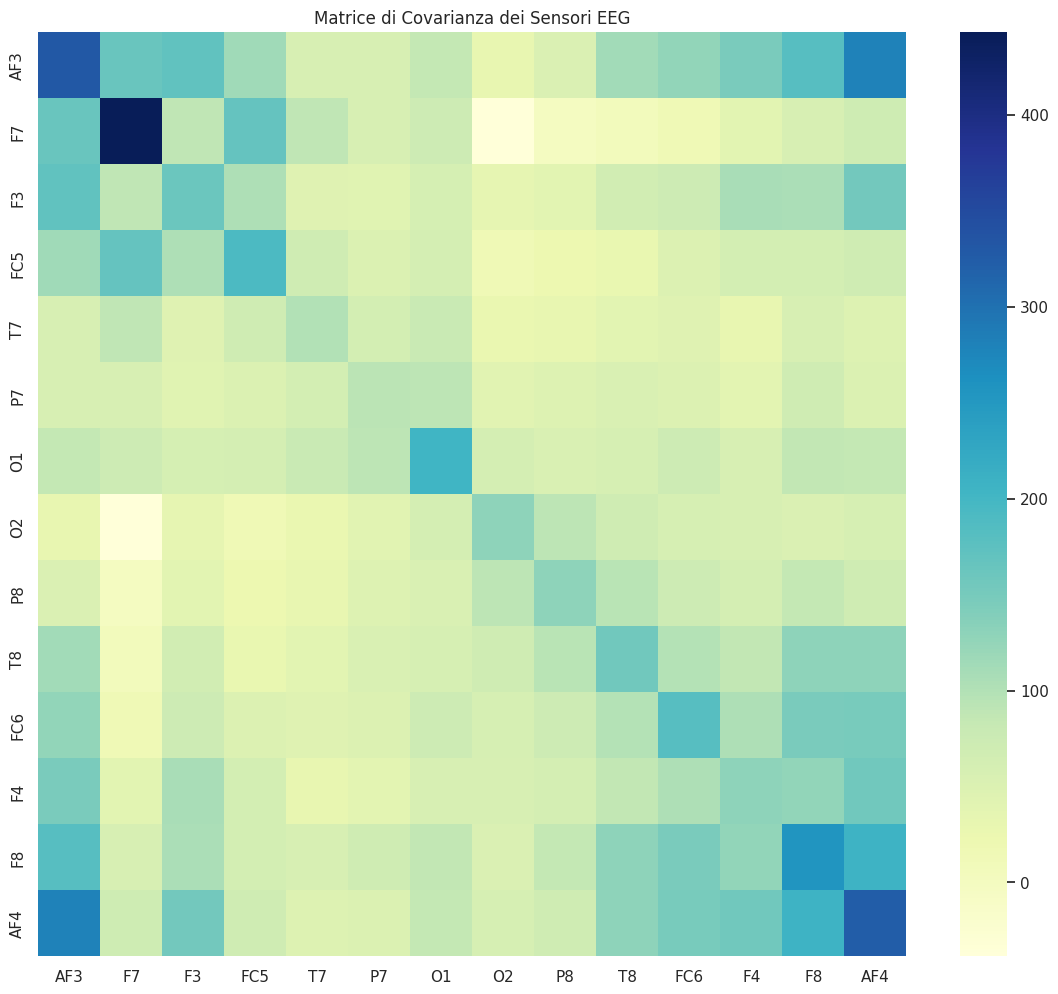

Correlazione con il target (Post-Cleaning):
AF4    0.282004
AF3    0.252929
F4     0.222072
F3     0.208657
T8     0.208640
FC6    0.131622
O2     0.126927
P8     0.071309
O1     0.061851
FC5    0.022376
F8     0.001554
T7    -0.044831
F7    -0.088783
P7    -0.180577
dtype: float64


In [ ]:
# RIMOZIONE OUTLIER TRAMITE IQR

eeg_features = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']

def compute_iqr_bounds(X_train, columns):
    bounds = {}
    for col in columns:
        Q1 = X_train[col].quantile(0.25)
        Q3 = X_train[col].quantile(0.75)
        IQR = Q3 - Q1
        bounds[col] = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    return bounds

def remove_outliers_iqr(X_train, bounds, columns):
    X_train_clean = X_train.copy()
    for col in columns:
        lower, upper = bounds[col]
        X_train_clean = X_train_clean[(X_train_clean[col] >= lower) & (X_train_clean[col] <= upper)]
    return X_train_clean

def clip_outliers_iqr(df_in, bounds, columns):
    df_out = df_in.copy()
    for col in columns:
        lower, upper = bounds[col]
        df_out[col] = df_out[col].clip(lower, upper)
    return df_out

bounds = compute_iqr_bounds(X_train, eeg_features)
X_train_clean = remove_outliers_iqr(X_train, bounds, eeg_features)
y_train_clean = y_train[X_train_clean.index]

print(f"Righe originali in X_train: {len(X_train)}")
print(f"Righe pulite in X_train:    {len(X_train_clean)}")
print(f"Outlier eliminati:          {len(X_train) - len(X_train_clean)}")

print("\nBilanciamento Target (Post-Cleaning):")
print(y_train_clean.value_counts(normalize=True) * 100)

X_val_clean = clip_outliers_iqr(X_val, bounds, eeg_features)
X_test_clean = clip_outliers_iqr(X_test, bounds, eeg_features)

print(f"\nRighe validation: {len(X_val)} (invariato)")
print(f"Righe test      : {len(X_test)} (invariato)")

# Matrice di Correlazione
corr_matrix = X_train_clean.corr()

# Analisi varianza
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train_clean)
low_variance_features = X_train_clean.columns[~selector.get_support()]
print("\nFeature a bassa varianza:")
print(low_variance_features if len(low_variance_features) > 0 else "Nessuna (tutti gli elettrodi sono informativi)")

# Controllo multicollinearità
high_corr = np.where(np.abs(corr_matrix) > 0.95)
high_corr_pairs = [(corr_matrix.columns[i], corr_matrix.columns[j])
                   for i, j in zip(*high_corr) if i < j]
print("\nFeature altamente correlate (>0.95):")
print(high_corr_pairs if high_corr_pairs else "Nessuna")

# Heatmap correlazione
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Matrice di Correlazione tra i Sensori EEG (Pearson)")
plt.show()

# Matrice di Covarianza
plt.figure(figsize=(14, 12))
cov_matrix = X_train_clean.cov()
sns.heatmap(cov_matrix, annot=False, cmap='YlGnBu')
plt.title("Matrice di Covarianza dei Sensori EEG")
plt.show()

# Correlazione con il target
corr_with_target = X_train_clean.corrwith(y_train_clean).sort_values(ascending=False)
print("Correlazione con il target (Post-Cleaning):")
print(corr_with_target)

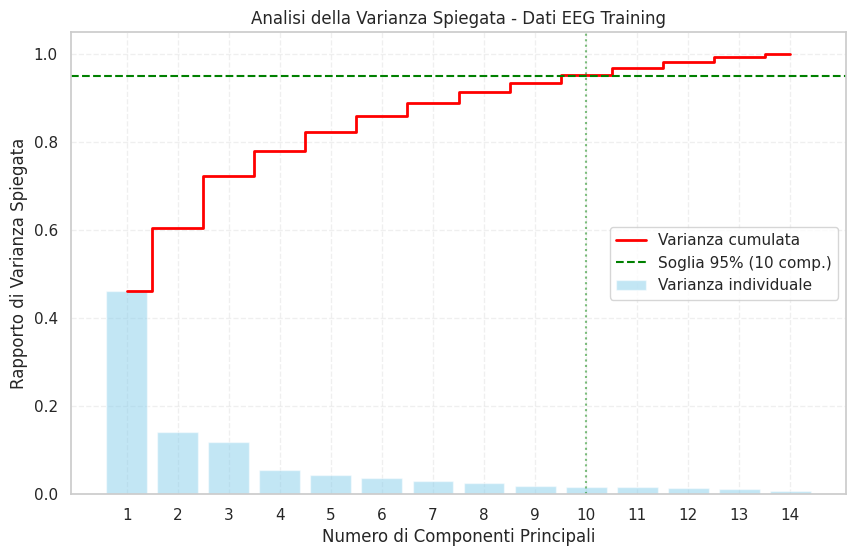

Risultati Analisi Varianza:
- Componenti per il 95% della varianza: 10
- Componenti per il 99% della varianza: 13
- Varianza spiegata dalla prima componente: 46.29%


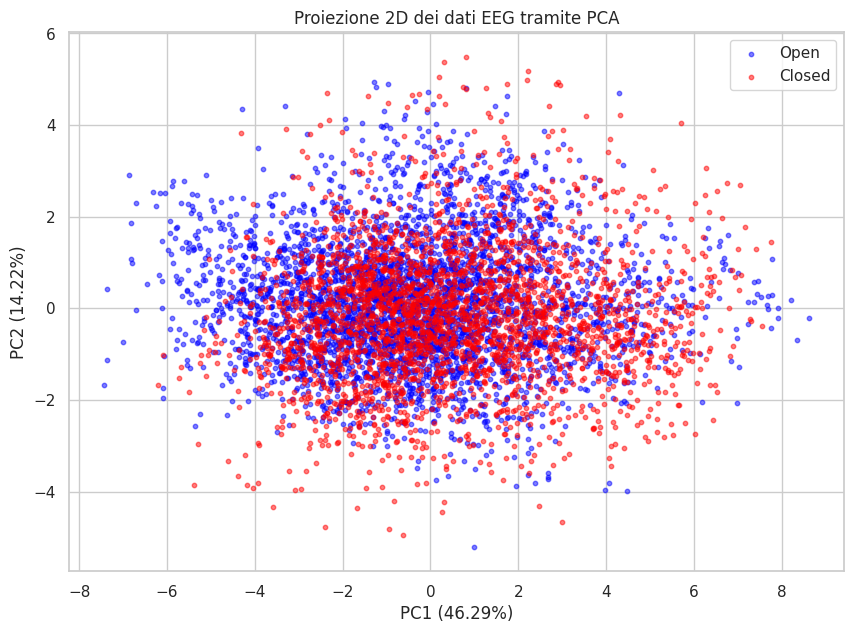

In [ ]:
# Copia scalata per analisi PCA
scaler_pca = StandardScaler()
X_train_clean_scaled_for_pca = scaler_pca.fit_transform(X_train_clean)

pca_esplorativa = PCA().fit(X_train_clean_scaled_for_pca)

# Calcolo varianza spiegata
exp_var_ratio = pca_esplorativa.explained_variance_ratio_
cum_var_ratio = np.cumsum(exp_var_ratio)

n_components_95 = np.where(cum_var_ratio >= 0.95)[0][0] + 1
n_components_99 = np.where(cum_var_ratio >= 0.99)[0][0] + 1


# scree plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var_ratio) + 1), exp_var_ratio, alpha=0.5, align='center',
        label='Varianza individuale', color='skyblue')
plt.step(range(1, len(cum_var_ratio) + 1), cum_var_ratio, where='mid',
         label='Varianza cumulata', color='red', linewidth=2)

# Linee di soglia
plt.axhline(y=0.95, color='green', linestyle='--', label=f'Soglia 95% ({n_components_95} comp.)')
plt.axvline(x=n_components_95, color='green', linestyle=':', alpha=0.5)

plt.title('Analisi della Varianza Spiegata - Dati EEG Training')
plt.xlabel('Numero di Componenti Principali')
plt.ylabel('Rapporto di Varianza Spiegata')
plt.xticks(range(1, len(exp_var_ratio) + 1))
plt.ylim(0, 1.05)
plt.legend(loc='center right')
plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.show()

print(f"Risultati Analisi Varianza:")
print(f"- Componenti per il 95% della varianza: {n_components_95}")
print(f"- Componenti per il 99% della varianza: {n_components_99}")
print(f"- Varianza spiegata dalla prima componente: {exp_var_ratio[0]*100:.2f}%")

# Proiettiamo i dati sulle prime 2 componenti
X_pca_2d = pca_esplorativa.transform(X_train_clean_scaled_for_pca)[:, :2]

y_target = np.array(y_train_clean)

plt.figure(figsize=(10, 7))
plt.scatter(X_pca_2d[y_target==0, 0], X_pca_2d[y_target==0, 1], label='Open', alpha=0.5, c='blue', s=10)
plt.scatter(X_pca_2d[y_target==1, 0], X_pca_2d[y_target==1, 1], label='Closed', alpha=0.5, c='red', s=10)
plt.xlabel(f'PC1 ({exp_var_ratio[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({exp_var_ratio[1]*100:.2f}%)')
plt.title('Proiezione 2D dei dati EEG tramite PCA')
plt.legend()
plt.show()

=== MODELLO DI BASELINE (Sempre classe 0) ===
Accuracy Baseline: 0.5348

=== GAUSSIAN NAIVE BAYES (PCA = 10 componenti) ===
Accuracy GaussianNB: 0.6300

Classification Report (Naive Bayes):
              precision    recall  f1-score   support

        Open       0.66      0.63      0.65      2674
      Closed       0.60      0.63      0.61      2326

    accuracy                           0.63      5000
   macro avg       0.63      0.63      0.63      5000
weighted avg       0.63      0.63      0.63      5000



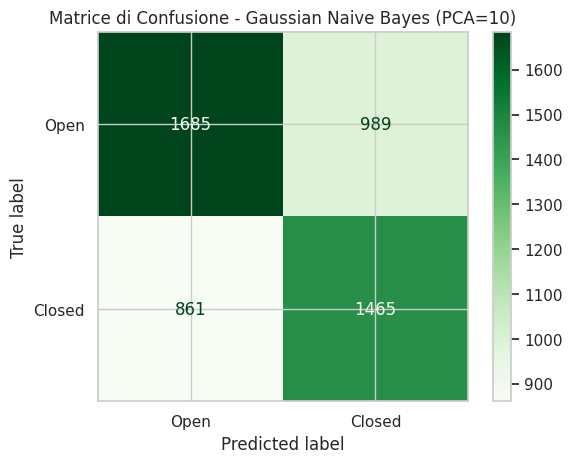

In [ ]:
#  MODELLO DI BASELINE
print("=== MODELLO DI BASELINE (Sempre classe 0) ===")

y_pred_baseline = np.zeros(y_test.shape)
acc_baseline = accuracy_score(y_test, y_pred_baseline)

print(f"Accuracy Baseline: {acc_baseline:.4f}\n")


# GAUSSIAN NAIVE BAYES
print("=== GAUSSIAN NAIVE BAYES (PCA = 10 componenti) ===")

# Pipeline
pipeline_nb = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10, random_state=1)),
    ('nb', GaussianNB())
])


pipeline_nb.fit(X_train_clean, y_train_clean)

y_pred_nb = pipeline_nb.predict(X_test_clean)

acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy GaussianNB: {acc_nb:.4f}\n")
print("Classification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb, target_names=['Open', 'Closed']))

cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(cm_nb, display_labels=['Open', 'Closed'])
disp_nb.plot(cmap='Greens')
plt.title("Matrice di Confusione - Gaussian Naive Bayes (PCA=10)")
plt.show()

Confusion matrix:
 [[2139  535]
 [ 787 1539]]

Accuracy del modello completo: 0.7356

Classification Report:
              precision    recall  f1-score   support

        Open       0.73      0.80      0.76      2674
      Closed       0.74      0.66      0.70      2326

    accuracy                           0.74      5000
   macro avg       0.74      0.73      0.73      5000
weighted avg       0.74      0.74      0.73      5000



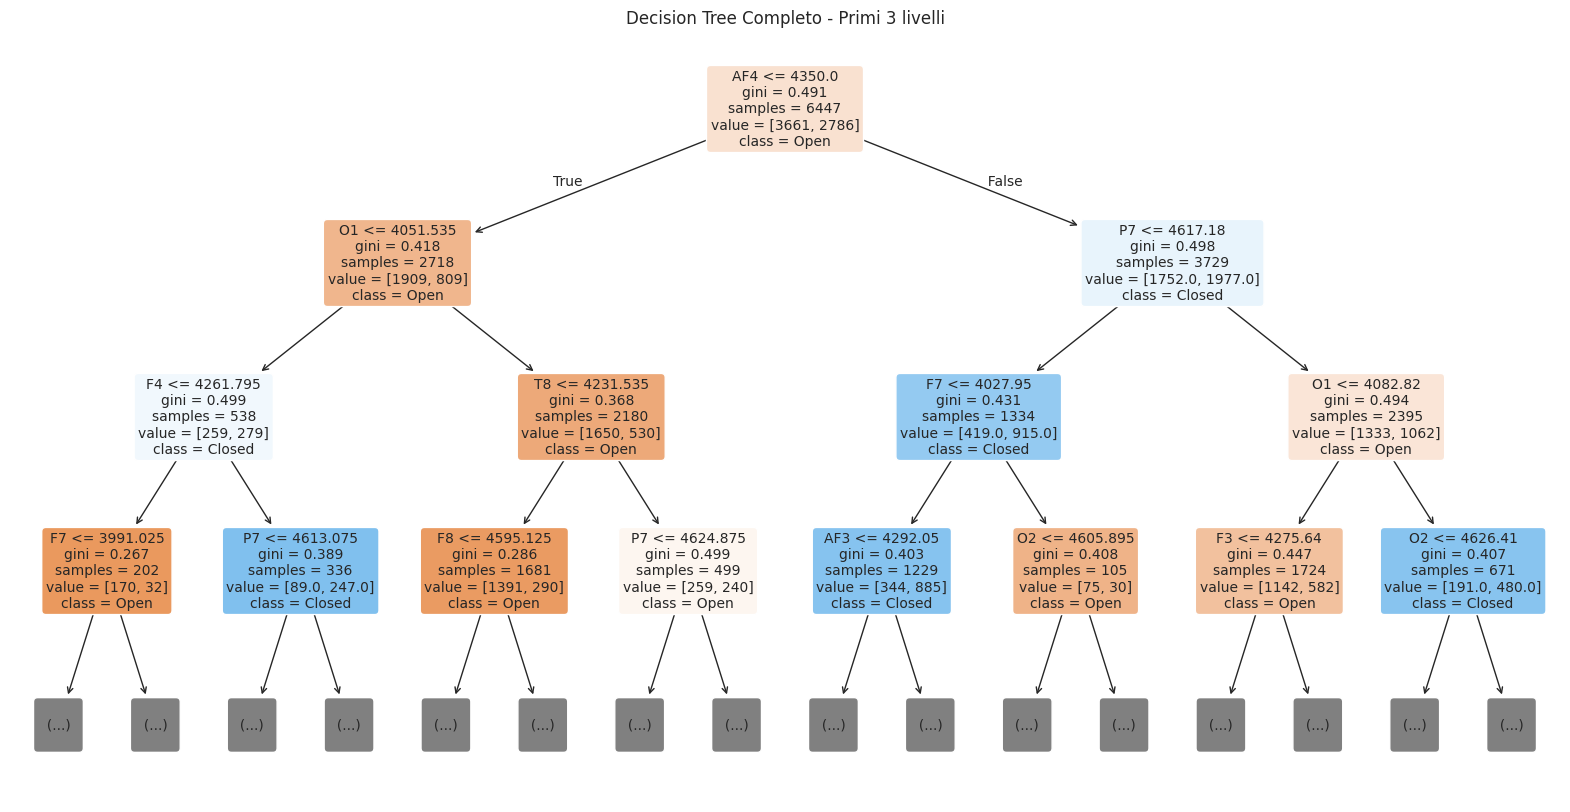

In [ ]:
# ALBERO COMPLETO


dt_model = DecisionTreeClassifier(random_state=1)
dt_model.fit(X_train_clean, y_train_clean)


y_pred_dt = dt_model.predict(X_test_clean)
acc_full = accuracy_score(y_test, y_pred_dt)


cm = confusion_matrix(y_test, y_pred_dt)
print("Confusion matrix:\n", cm)
print(f"\nAccuracy del modello completo: {acc_full:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Open', 'Closed']))

# Visualizzazione albero
plt.figure(figsize=(20, 10))
plot_tree(dt_model,
               feature_names=X_train_clean.columns,
               class_names=['Open', 'Closed'],
               filled=True,
               rounded=True,
               max_depth=3,
               fontsize=10,
               )
plt.title("Decision Tree Completo - Primi 3 livelli")
plt.show()


Testa 409 valori di Alpha


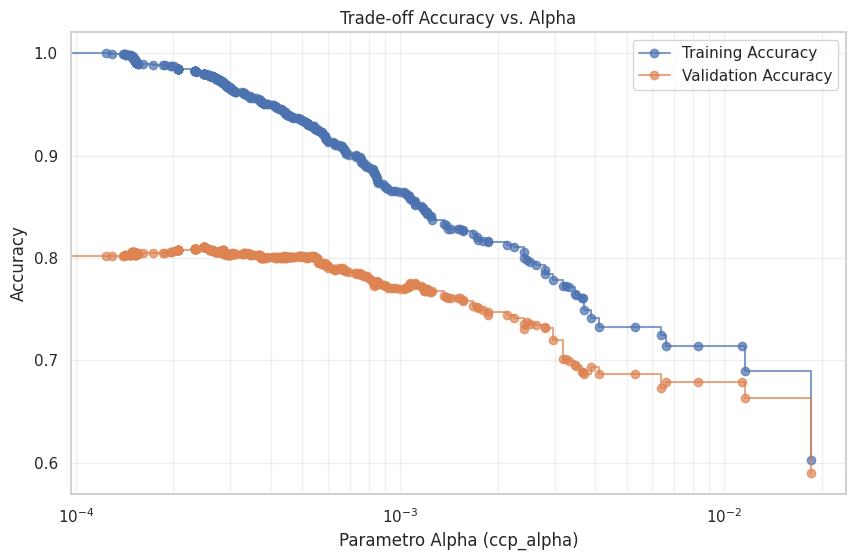

Alpha ottimale individuato (massimizza il Validation Score): 0.000248
Accuratezza raggiunta sul Validation: 0.8106


In [ ]:
# PRUNING

# Calcoliamo tutti i possibili alpha per training set
path_alphas = DecisionTreeClassifier(random_state=1).cost_complexity_pruning_path(X_train_clean, y_train_clean)
ccp_alphas = path_alphas.ccp_alphas[:-1]

train_accuracy = []
val_accuracy = []

print(f"Testa {len(ccp_alphas)} valori di Alpha")

# Per ogni alpha addestriamo un albero e calcoliamo l'accuratezza
for complexity in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=complexity)
    clf.fit(X_train_clean, y_train_clean)
    train_accuracy.append(clf.score(X_train_clean, y_train_clean))
    val_accuracy.append(clf.score(X_val_clean, y_val))

# Grafico del Trade-off
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, train_accuracy, marker='o', label='Training Accuracy', drawstyle="steps-post", alpha=0.7)
plt.plot(ccp_alphas, val_accuracy, marker='o', label='Validation Accuracy', drawstyle="steps-post", alpha=0.7)
plt.xlabel('Parametro Alpha (ccp_alpha)')
plt.ylabel('Accuracy')
plt.title('Trade-off Accuracy vs. Alpha')
plt.xscale('log')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

#  Alpha Ottimale
max_val_acc = max(val_accuracy)
best_alpha = ccp_alphas[max(i for i, v in enumerate(val_accuracy) if v == max_val_acc)]
print(f"Alpha ottimale individuato (massimizza il Validation Score): {best_alpha:.6f}")
print(f"Accuratezza raggiunta sul Validation: {max_val_acc:.4f}")

=== DECISION TREE OTTIMIZZATO ===
Accuracy sul Test Set: 0.7290

              precision    recall  f1-score   support

        Open       0.72      0.81      0.76      2674
      Closed       0.74      0.64      0.69      2326

    accuracy                           0.73      5000
   macro avg       0.73      0.72      0.72      5000
weighted avg       0.73      0.73      0.73      5000



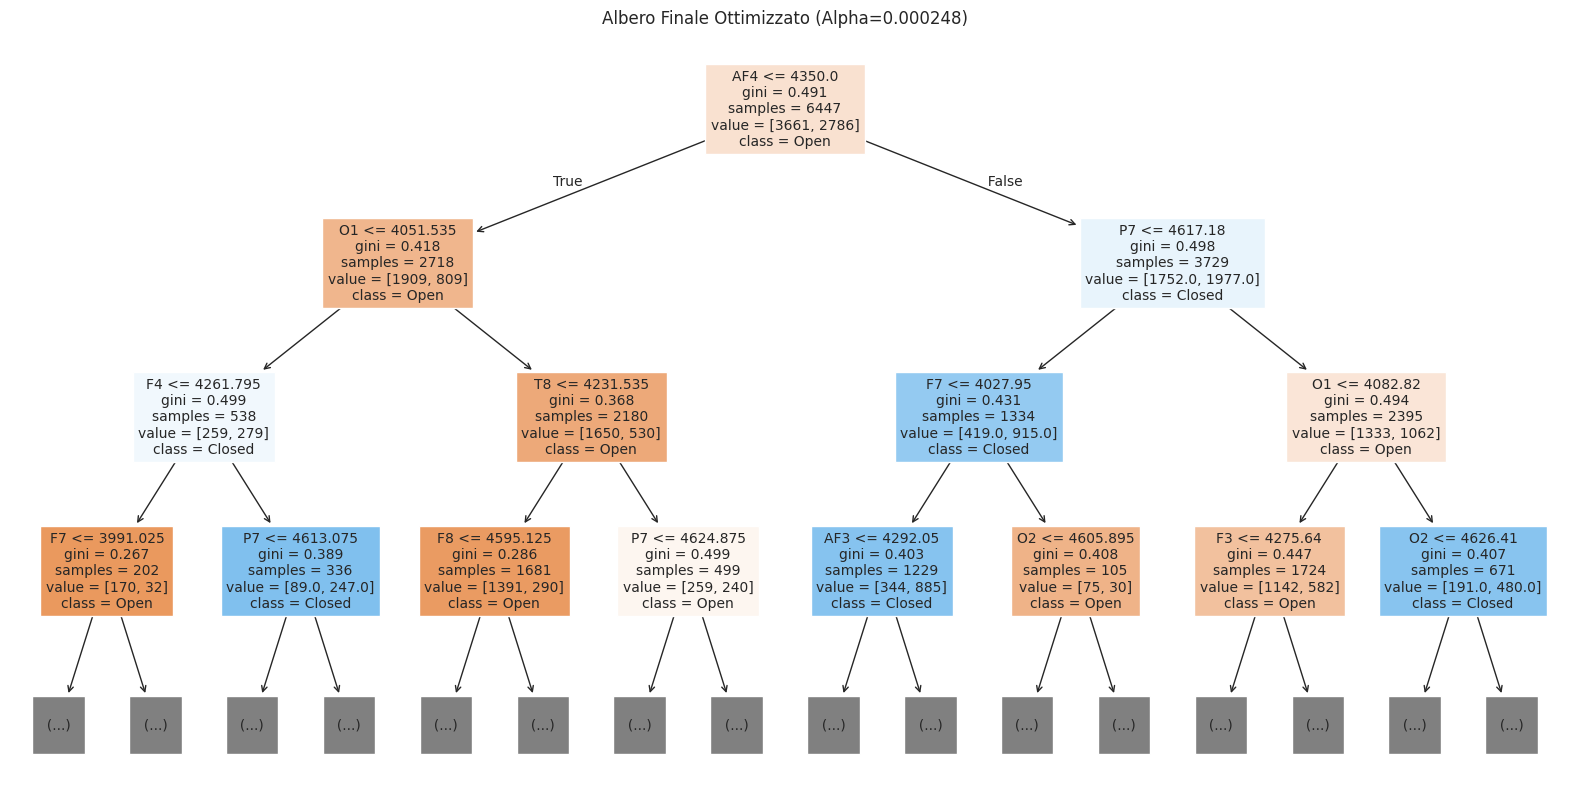

--- CONFRONTO COMPLESSITÀ ---
Albero COMPLETO: Profondità = 20 | Nodi = 1319
Albero POTATO  : Profondità = 20 | Nodi = 909
Riduzione numero di nodi: 31.08%


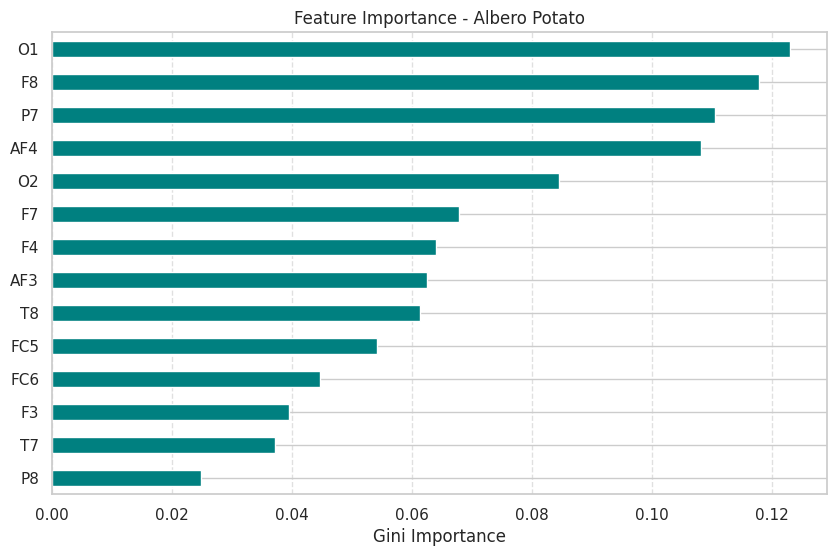

In [ ]:
# Albero finale con Alpha ottimale
final_dt = DecisionTreeClassifier(random_state=1, ccp_alpha=best_alpha)
final_dt.fit(X_train_clean, y_train_clean)

# Predizione e Valutazione sul Test
y_pred_final_dt = final_dt.predict(X_test_clean)
acc_final_dt = accuracy_score(y_test, y_pred_final_dt)

print("=== DECISION TREE OTTIMIZZATO ===")
print(f"Accuracy sul Test Set: {acc_final_dt:.4f}\n")
print(classification_report(y_test, y_pred_final_dt, target_names=['Open', 'Closed']))

# Visualizzazione dell'Albero Potato
plt.figure(figsize=(20, 10))
plot_tree(final_dt,
               filled=True,
               feature_names=X_train_clean.columns,
               class_names=['Open', 'Closed'],
               max_depth=3,
               fontsize=10)
plt.title(f"Albero Finale Ottimizzato (Alpha={best_alpha:.6f})")
plt.show()


print("--- CONFRONTO COMPLESSITÀ ---")
print(f"Albero COMPLETO: Profondità = {dt_model.get_depth()} | Nodi = {dt_model.tree_.node_count}")
print(f"Albero POTATO  : Profondità = {final_dt.get_depth()} | Nodi = {final_dt.tree_.node_count}")
print(f"Riduzione numero di nodi: {((dt_model.tree_.node_count - final_dt.tree_.node_count) / dt_model.tree_.node_count * 100):.2f}%")


# Feature Importance
plt.figure(figsize=(10, 6))
importances = pd.Series(final_dt.feature_importances_, index=X_train_clean.columns)
importances = importances[importances > 0].sort_values()
importances.plot(kind='barh', color='teal')
plt.title("Feature Importance - Albero Potato")
plt.xlabel("Gini Importance")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# SVM con Kernel Lineare
print("\n--- SVM Kernel Lineare ---")
pipeline_svm_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('svm_linear', SVC(kernel='linear', probability=True, random_state=1))
])

pipeline_svm_linear.fit(X_train_clean, y_train_clean)
y_pred_svm_linear = pipeline_svm_linear.predict(X_test_clean)

acc_linear = accuracy_score(y_test, y_pred_svm_linear)
print(f"Accuracy SVM Lineare: {acc_linear:.4f}")
print(classification_report(y_test, y_pred_svm_linear, target_names=['Open', 'Closed']))

# SVM con Kernel RBF
print("\n--- SVM Kernel RBF ---")
pipeline_svm_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm_rbf', SVC(kernel='rbf', random_state=1))
])

pipeline_svm_rbf.fit(X_train_clean, y_train_clean)
y_pred_svm_rbf = pipeline_svm_rbf.predict(X_test_clean)

acc_rbf = accuracy_score(y_test, y_pred_svm_rbf)
print(f"Accuracy SVM RBF: {acc_rbf:.4f}")
print(classification_report(y_test, y_pred_svm_rbf, target_names=['Open', 'Closed']))


--- SVM Kernel Lineare ---
Accuracy SVM Lineare: 0.6386
              precision    recall  f1-score   support

        Open       0.68      0.61      0.64      2674
      Closed       0.60      0.67      0.63      2326

    accuracy                           0.64      5000
   macro avg       0.64      0.64      0.64      5000
weighted avg       0.64      0.64      0.64      5000


--- SVM Kernel RBF ---
Accuracy SVM RBF: 0.7566
              precision    recall  f1-score   support

        Open       0.74      0.83      0.78      2674
      Closed       0.78      0.67      0.72      2326

    accuracy                           0.76      5000
   macro avg       0.76      0.75      0.75      5000
weighted avg       0.76      0.76      0.75      5000




=== SVM RBF - Cross Validation ===
C=  0.1 -> Accuracy media CV: 0.8736
C=    1 -> Accuracy media CV: 0.9308
C=   10 -> Accuracy media CV: 0.9615
C=  100 -> Accuracy media CV: 0.9634

Miglior C (RBF): 100

=== SVM RBF - Test Set (Performance Finale) ===
Accuracy: 0.7680
Precision: 0.773
Recall: 0.709
F1 Score: 0.740

Classification Report:
              precision    recall  f1-score   support

        Open       0.76      0.82      0.79      2674
      Closed       0.77      0.71      0.74      2326

    accuracy                           0.77      5000
   macro avg       0.77      0.76      0.77      5000
weighted avg       0.77      0.77      0.77      5000



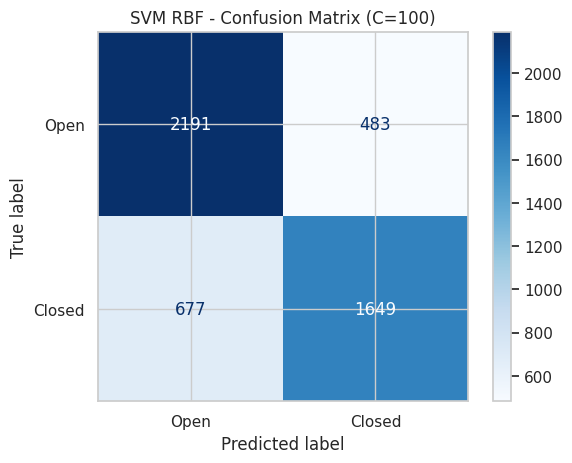

Numero di support vectors (RBF): 913 su 6447 campioni


In [ ]:
# SVM RBF CON CROSS VALIDATION

print("\n=== SVM RBF - Cross Validation ===")
cv_scores_rbf = []

C_values = [0.1, 1, 10, 100]

for C in C_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=C, gamma='scale', random_state=1))
    ])

    scores = cross_val_score(pipe, X_train_clean, y_train_clean, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    cv_scores_rbf.append(mean_score)

    print(f"C={C:>5} -> Accuracy media CV: {mean_score:.4f}")

# Miglior C per RBF
best_C_rbf = C_values[np.argmax(cv_scores_rbf)]
print(f"\nMiglior C (RBF): {best_C_rbf}")

# Modello finale
pipeline_best_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=best_C_rbf, gamma='scale', probability=True, random_state=1))
])

pipeline_best_rbf.fit(X_train_clean, y_train_clean)

y_pred_rbf = pipeline_best_rbf.predict(X_test_clean)

# Valutazione finale
print("\n=== SVM RBF - Test Set (Performance Finale) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rbf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rbf):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_rbf):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rbf):.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf, target_names=['Open', 'Closed']))

cm_rbf = confusion_matrix(y_test, y_pred_rbf)
disp = ConfusionMatrixDisplay(cm_rbf, display_labels=['Open', 'Closed'])
disp.plot(cmap='Blues')
plt.title(f"SVM RBF - Confusion Matrix (C={best_C_rbf})")
plt.show()

# Support Vectors
n_sv_rbf = pipeline_best_rbf.named_steps['svm'].support_vectors_.shape[0]
print(f"Numero di support vectors (RBF): {n_sv_rbf} su {X_train_clean.shape[0]} campioni")

=== CURVE ROC ===


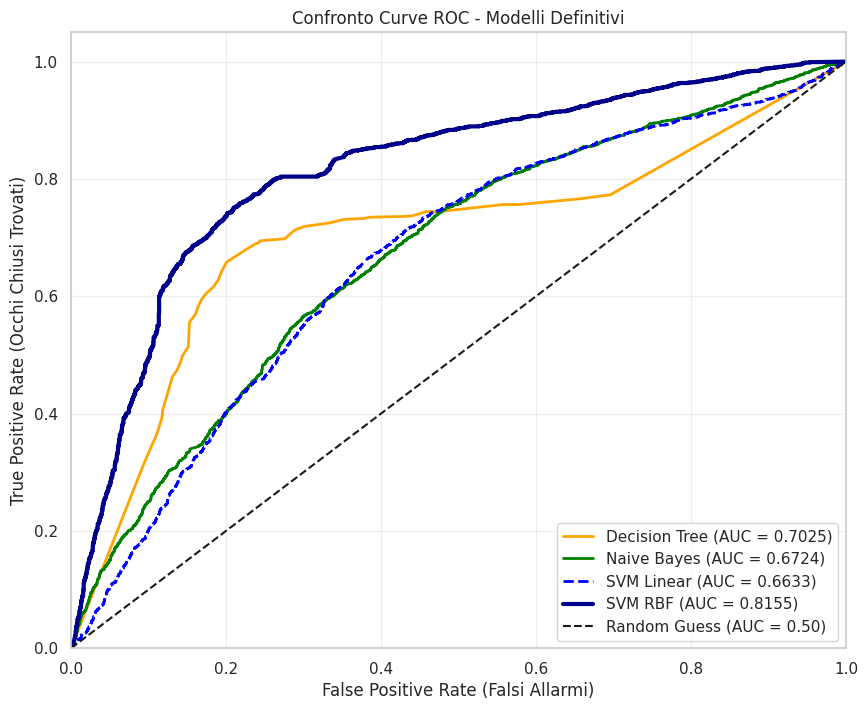


--- RISULTATI AREA SOTTO LA CURVA (AUC) ---
AUC SVM RBF:       0.8155
AUC Decision Tree: 0.7025
AUC SVM Linear:    0.6633
AUC Naive Bayes:   0.6724


In [ ]:
# CURVE ROC

# Calcolo delle probabilità predette per la classe 1 = Closed
y_dt_prob  = final_dt.predict_proba(X_test_clean)[:, 1]
y_nb_prob  = pipeline_nb.predict_proba(X_test_clean)[:, 1]
y_svm_l_prob = pipeline_svm_linear.predict_proba(X_test_clean)[:, 1]
y_svm_r_prob = pipeline_best_rbf.predict_proba(X_test_clean)[:, 1]

# Calcolo dei tassi (FPR, TPR) e dell'AUC
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_dt_prob)
auc_dt = roc_auc_score(y_test, y_dt_prob)

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_nb_prob)
auc_nb = roc_auc_score(y_test, y_nb_prob)

fpr_svm_l, tpr_svm_l, _ = roc_curve(y_test, y_svm_l_prob)
auc_svm_l = roc_auc_score(y_test, y_svm_l_prob)

fpr_svm_r, tpr_svm_r, _ = roc_curve(y_test, y_svm_r_prob)
auc_svm_r = roc_auc_score(y_test, y_svm_r_prob)

# Grafico
plt.figure(figsize=(10, 8))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.4f})', linewidth=2, color='orange')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.4f})', linewidth=2, color='green')
plt.plot(fpr_svm_l, tpr_svm_l, label=f'SVM Linear (AUC = {auc_svm_l:.4f})', linewidth=2, color='blue', linestyle='--')
plt.plot(fpr_svm_r, tpr_svm_r, label=f'SVM RBF (AUC = {auc_svm_r:.4f})', linewidth=3, color='darkblue')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Falsi Allarmi)')
plt.ylabel('True Positive Rate (Occhi Chiusi Trovati)')
plt.title('Confronto Curve ROC - Modelli Definitivi')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print("\n--- RISULTATI AREA SOTTO LA CURVA (AUC) ---")
print(f"AUC SVM RBF:       {auc_svm_r:.4f}")
print(f"AUC Decision Tree: {auc_dt:.4f}")
print(f"AUC SVM Linear:    {auc_svm_l:.4f}")
print(f"AUC Naive Bayes:   {auc_nb:.4f}")

In [ ]:
# EFFICIENZA COMPUTAZIONALE

model_list = {
    'Decision Tree': final_dt,
    'Naive Bayes (PCA)': pipeline_nb,
    'SVM Linear': pipeline_svm_linear,
    'SVM RBF': pipeline_best_rbf
}

for name, model in model_list.items():
    model_copy = clone(model)
    start_time = time()
    model_copy.fit(X_train_clean, y_train_clean)
    end_time = time()
    duration = end_time - start_time

    print(f"Tempo di training per {name:18}: {duration:.4f} secondi")

Tempo di training per Decision Tree     : 0.0706 secondi
Tempo di training per Naive Bayes (PCA) : 0.0065 secondi
Tempo di training per SVM Linear        : 5.5726 secondi
Tempo di training per SVM RBF           : 3.4910 secondi


In [ ]:
# VALUTAZIONE FINALE: REPEATED STRATIFIED CV (50 TEST)

# Uniamo i dataset puliti
X_final_clean = pd.concat([X_train_clean, X_test_clean]).reset_index(drop=True)
y_final_clean = pd.concat([y_train_clean, y_test]).reset_index(drop=True)

# Definiamo i modelli definitivi
model_list = {
    'Decision Tree': final_dt,
    'Naive Bayes (PCA)': pipeline_nb,
    'SVM Linear': pipeline_svm_linear,
    'SVM RBF': pipeline_best_rbf
}

# 10 fold x 5 ripetizioni
rkf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=1)

results_means = []
results_cis = []
labels_list = []

print(f"=== ANALISI STATISTICA (Campione: {len(X_final_clean)} record puliti) ===")
print("Esecuzione di 50 iterazioni per modello\n")

for name, model in model_list.items():
    acc_rep = []

    for train_idx, valid_idx in rkf.split(X_final_clean, y_final_clean):
        X_t, X_v = X_final_clean.iloc[train_idx], X_final_clean.iloc[valid_idx]
        y_t, y_v = y_final_clean.iloc[train_idx], y_final_clean.iloc[valid_idx]

        m_tmp = clone(model)

        m_tmp.fit(X_t, y_t)
        y_pred_v = m_tmp.predict(X_v)

        acc_rep.append(accuracy_score(y_v, y_pred_v))

    m_val = np.mean(acc_rep)

    ci_val = st.t.interval(confidence=0.95, df=len(acc_rep)-1,
                           loc=m_val, scale=st.sem(acc_rep))

    print(f"{name:18}: Media Acc. = {m_val:.4f} | IC 95% = ({ci_val[0]:.4f}, {ci_val[1]:.4f})")

    results_means.append(m_val)
    results_cis.append(ci_val)
    labels_list.append(name)

plt.figure(figsize=(12, 7))
for i in range(len(labels_list)):
    yerr = (results_cis[i][1] - results_cis[i][0]) / 2
    plt.errorbar(i, results_means[i], yerr=yerr, fmt='o', capsize=12,
                 elinewidth=3, markeredgewidth=3, markersize=8, label=labels_list[i])

plt.xticks(range(len(labels_list)), labels_list)
plt.ylabel('Accuratezza Media (50 Fold)')
plt.title('Stabilità dei Modelli (IC 95%)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

=== ANALISI STATISTICA (Campione: 11447 record puliti) ===
Esecuzione di 50 iterazioni per modello

Decision Tree     : Media Acc. = 0.8564 | IC 95% = (0.8533, 0.8595)
Naive Bayes (PCA) : Media Acc. = 0.7008 | IC 95% = (0.6974, 0.7043)
SVM Linear        : Media Acc. = 0.7088 | IC 95% = (0.7048, 0.7128)
